<a href="https://colab.research.google.com/github/MabelSSantos/GEDI_start/blob/main/6_Filtering_Outliers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**FILTERING AND OUTLIERS**




This notebook filters GEDI fire‑pair data to identify and remove outliers in biomass change (ΔAGBD) and assess the robustness of results across regions and conditions.

Workflow:
* Load the GEDI fire‑pair dataset with NDVI, season, and subregion attributes.
Select relevant variables.
* Identify ΔAGBD outliers within subregions using both interquartile range (IQR) and ±2.5 standard deviation methods.
* Compare outlier definitions, quantify their overlap, and summarize their prevalence by subregion.
* Evaluate how outliers relate to NDVI change, fire timing, and other covariates using visualizations and statistical models.
* Apply final filtering criteria and save a cleaned GEDI fire‑pair dataset for downstream analysis.


In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import ee
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2_contingency
from google.colab import drive
from statsmodels.stats.power import TTestPower
from pathlib import Path

In [2]:
!pip -q install geopandas pyogrio shapely pyproj rtree seaborn statsmodels folium
sns.set(style="whitegrid", context="talk")
pd.set_option('display.max_columns', 200)

In [3]:
ee.Authenticate()
ee.Initialize(project='instant-pivot-489802-p0')

In [4]:
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [5]:
#Input and output paths

#db_path = Path("/content/drive/MyDrive/GEDI/GEDIdb/GEDI_Footprint_Fire_Pairs_FF_FYs_NDVI_region.gpkg")
#db_50_path = Path("/content/drive/MyDrive/GEDI/GEDIdb/GEDI_Footprint_50_Fire_Pairs_FF_FYs_NDVI_region.gpkg")
db_25_path = Path("/content/drive/MyDrive/GEDI/GEDIdb/GEDI_Footprint_25_Fire_Pairs_FF_FYs_NDVI_subregion_retry.gpkg")

out_path = Path("/content/drive/MyDrive/GEDI/GEDIdb/GEDI__Pairs_Final.gpkg")


In [6]:
test=gpd.read_file(db_25_path)
test.head()

test.shape[0]

5972

In [7]:
# Columns we will keep (from your list)
KEEP_COLS = [
    'pair_uid','index_1','index_2','distance_m','fire','time_1','fire_date','time_2',
    'season','fire_frequency','fire_years','pre_veg_age','post_fire_months',
    'agbd_1','agbd_2','delta_agbd','agbd_se_1','agbd_se_2',
    'rh_98_1','rh_98_2','rh_90_1','rh_90_2','rh_50_1','rh_50_2',
    'cover_1','cover_2','pai_1','pai_2','wsci_1','wsci_2',
    'img_date','ndvi_1','ndvi_2','delta_ndvi','delta_ndvi_abs',
    'subregion','shot_number_1','shot_number_2','pairing_crs'
    'geometry_1','geometry_2','geometry'
]

def read_gpkg(path, dataset_name=None):
    gdf = gpd.read_file(path)
    # keep only columns we need
    keep = [c for c in KEEP_COLS if c in gdf.columns]
    gdf = gdf[keep].copy()
    gdf['dataset'] = dataset_name

    try:
        if gdf.geometry is not None and gdf.crs and gdf.crs.to_epsg() != 4326:
            gdf = gdf.to_crs(4326)
    except Exception:
        pass
    return gdf



GDF = read_gpkg(db_25_path)


print("Rows by dataset:")
print(GDF['subregion'].value_counts(dropna=False))


Rows by dataset:
subregion
west       2972
central    2708
east        292
Name: count, dtype: int64


In [8]:
print(GDF.columns)

Index(['pair_uid', 'index_1', 'index_2', 'distance_m', 'fire', 'time_1',
       'fire_date', 'time_2', 'season', 'fire_frequency', 'fire_years',
       'pre_veg_age', 'post_fire_months', 'agbd_1', 'agbd_2', 'delta_agbd',
       'agbd_se_1', 'agbd_se_2', 'rh_98_1', 'rh_98_2', 'rh_90_1', 'rh_90_2',
       'rh_50_1', 'rh_50_2', 'cover_1', 'cover_2', 'pai_1', 'pai_2', 'wsci_1',
       'wsci_2', 'img_date', 'ndvi_1', 'ndvi_2', 'delta_ndvi',
       'delta_ndvi_abs', 'subregion', 'shot_number_1', 'shot_number_2',
       'geometry_2', 'geometry', 'dataset'],
      dtype='object')


In [11]:
##### FILTERING ######

GDF["delta_ndvi_abs"] = pd.to_numeric(
    GDF["delta_ndvi_abs"],
    errors="coerce"
)

GDF["post_fire_months"] = pd.to_numeric(
    GDF["post_fire_months"],
    errors="coerce"
)

GDF = GDF[
    (GDF['delta_ndvi_abs'] <= 0.05) &
    (GDF['post_fire_months'] <= 24)
]


print("Rows by dataset:")
print(GDF['subregion'].value_counts(dropna=False))

In [12]:
print("Rows by dataset:")
print(GDF['subregion'].value_counts(dropna=False))

Rows by dataset:
subregion
west       2418
central    1437
east        199
Name: count, dtype: int64


In [13]:
#######         OUTLIERS        #######

# Analzing two methods to find the outliers
# IQR -> Interquartile Range (IQR) method detects outliers by defining a "fence" around the middle 50% of data, spanning from below the first quartile to above
        # the third quartile. Data points falling outside this range are considered outliers. Usually stricter than 2.5 SD (eliminates more data).

# 2.5 SD -> Outliers at 2.5 standard deviations are data points that fall outside the range of mean +- 2.5 SD.

work = GDF.copy()
group_cols = ['subregion']
target = 'delta_agbd'

# IQR flags (within groups)
g = work.groupby(group_cols, dropna=False)
q1 = g[target].transform(lambda x: x.quantile(0.25))
q3 = g[target].transform(lambda x: x.quantile(0.75))
iqr = q3 - q1
work['iqr_lower'] = q1 - 1.5*iqr
work['iqr_upper'] = q3 + 1.5*iqr
work['out_iqr']   = (work[target] < work['iqr_lower']) | (work[target] > work['iqr_upper'])

# ±2.5 SD flags (within groups)
mu  = g[target].transform('mean')
sd  = g[target].transform('std')
k = 2.5
work['sd_lower'] = mu - k*sd
work['sd_upper'] = mu + k*sd
work['out_sd25'] = (work[target] < work['sd_lower']) | (work[target] > work['sd_upper'])

# Compare overlap
n = len(work)
n_iqr   = work['out_iqr'].sum()
n_sd25  = work['out_sd25'].sum()
n_both  = (work['out_iqr'] & work['out_sd25']).sum()
print(f"N={n}, IQR outliers={n_iqr} ({n_iqr/n:.2%}), ±2.5SD outliers={n_sd25} ({n_sd25/n:.2%}), overlap={n_both} ({n_both/n:.2%})")




N=4054, IQR outliers=361 (8.90%), ±2.5SD outliers=124 (3.06%), overlap=124 (3.06%)


In [14]:
# Summary by subregion

group_cols = [c for c in ['subregion'] if c in work.columns]

fences_from_columns = (
    work
    .groupby(group_cols, dropna=False)
    .agg(
        n=('pair_uid', 'size'),
        n_iqr=('out_iqr', 'sum'),
        n_sd25=('out_sd25', 'sum'),
        iqr_lower=('iqr_lower', 'first'),
        iqr_upper=('iqr_upper', 'first'),
        sd25_lower=('sd_lower', 'first'),   # these came from k=2.5 when we built out_sd25
        sd25_upper=('sd_upper', 'first')
    )
    .reset_index()
)

# Nicely formatted table
fences_from_columns_rounded = fences_from_columns.copy()
for c in ['iqr_lower','iqr_upper','sd25_lower','sd25_upper']:
    fences_from_columns_rounded[c] = fences_from_columns_rounded[c].astype(float).round(2)

fences_from_columns_rounded



,subregion,n,n_iqr,n_sd25,iqr_lower,iqr_upper,sd25_lower,sd25_upper
0,central,1437,152,30,-155.26,215.21,-328.69,390.43
1,east,199,8,4,-200.77,332.33,-277.48,428.43
2,west,2418,201,90,-160.22,236.95,-233.66,316.19


In [15]:
#Characterize the two sets of outliers
# Define groups
set_sd = work['out_sd25']
set_iqr = work['out_iqr']
iqr_only = set_iqr & ~set_sd
clean = ~(set_iqr | set_sd)

def summarize_slice(df, label):
    return pd.Series({
        'n': len(df),
        'mean_delta': df['delta_agbd'].mean(),
        'median_delta': df['delta_agbd'].median(),
        'std_delta': df['delta_agbd'].std(),

        'mean_timedelta_days': (
            pd.to_numeric(df['timedelta_days'], errors='coerce').mean()
            if 'timedelta_days' in df.columns else np.nan
        ),

        'mean_post_fire_months': (
            pd.to_numeric(df['post_fire_months'], errors='coerce').mean()
            if 'post_fire_months' in df.columns else np.nan
        ),

        'mean_delta_ndvi': (
            pd.to_numeric(df['delta_ndvi'], errors='coerce').mean()
            if 'delta_ndvi' in df.columns else np.nan
        ),

        'pos_frac': (df['delta_agbd'] > 0).mean()
    }, name=label)

view = pd.concat([
    summarize_slice(work[clean], 'Non-outliers'),
    summarize_slice(work[set_sd], '±2.5SD outliers'),
    summarize_slice(work[iqr_only], 'IQR-only outliers')
], axis=1)
view


,Non-outliers,±2.5SD outliers,IQR-only outliers
n,3693.000000,124.000000,237.000000
mean_delta,29.751959,173.426590,117.212158
median_delta,14.146153,346.513794,250.493851
std_delta,72.884697,467.269409,232.690582
mean_timedelta_days,NaN,NaN,NaN
mean_post_fire_months,13.412943,15.346774,13.839662
mean_delta_ndvi,0.000070,0.000658,-0.000758
pos_frac,0.634444,0.661290,0.666667


In [16]:
print(work.columns)

Index(['pair_uid', 'index_1', 'index_2', 'distance_m', 'fire', 'time_1',
       'fire_date', 'time_2', 'season', 'fire_frequency', 'fire_years',
       'pre_veg_age', 'post_fire_months', 'agbd_1', 'agbd_2', 'delta_agbd',
       'agbd_se_1', 'agbd_se_2', 'rh_98_1', 'rh_98_2', 'rh_90_1', 'rh_90_2',
       'rh_50_1', 'rh_50_2', 'cover_1', 'cover_2', 'pai_1', 'pai_2', 'wsci_1',
       'wsci_2', 'img_date', 'ndvi_1', 'ndvi_2', 'delta_ndvi',
       'delta_ndvi_abs', 'subregion', 'shot_number_1', 'shot_number_2',
       'geometry_2', 'geometry', 'dataset', 'iqr_lower', 'iqr_upper',
       'out_iqr', 'sd_lower', 'sd_upper', 'out_sd25'],
      dtype='object')


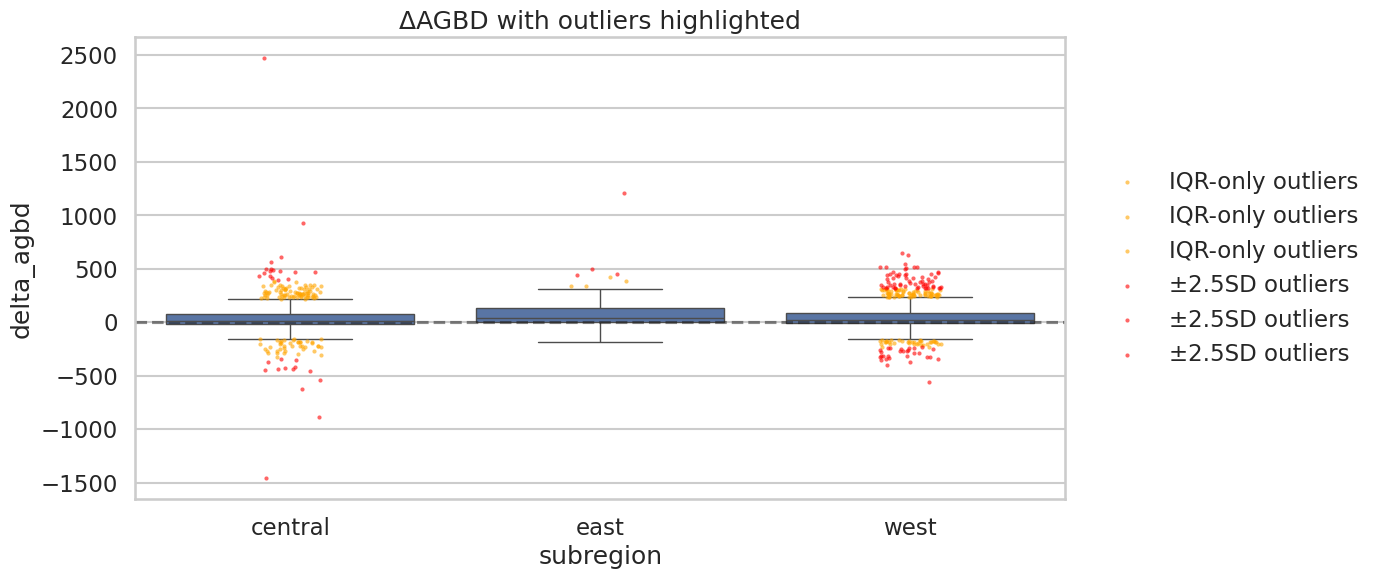

In [17]:
# Boxplot of ΔAGBD highlighting IQR-only points
plt.figure(figsize=(12,6))
sns.boxplot(data=work, x='subregion', y='delta_agbd', showfliers=False)
sns.stripplot(data=work[iqr_only], x='subregion', y='delta_agbd',
              color='orange', size=3, alpha=0.6, jitter=True, label='IQR-only outliers')
sns.stripplot(data=work[set_sd], x='subregion', y='delta_agbd',
              color='red', size=3, alpha=0.6, jitter=True, label='±2.5SD outliers')
plt.axhline(0, color='k', ls='--', alpha=0.5)
plt.title('ΔAGBD with outliers highlighted')
plt.legend(loc='center left',
           bbox_to_anchor=(1.02, 0.5),
           frameon=False)
plt.show()


In [18]:
def stats_view(df, label):
    return pd.Series({
        'n': len(df),
        'mean_delta': df['delta_agbd'].mean(),
        'median_delta': df['delta_agbd'].median(),
        'std_delta': df['delta_agbd'].std(),
        'pos_frac': (df['delta_agbd']>0).mean()
    }, name=label)

views = []
views.append(stats_view(work, 'All'))
views.append(stats_view(work[~work['out_sd25']], 'No ±2.5SD'))
views.append(stats_view(work[~work['out_iqr']], 'No IQR'))
pd.concat(views, axis=1)


,All,No ±2.5SD,No IQR
n,4054.000000,3930.000000,3693.000000
mean_delta,39.259541,35.026279,29.751959
median_delta,16.285061,15.451464,14.146153
std_delta,124.925537,93.153656,72.884697
pos_frac,0.637148,0.636387,0.634444


In [19]:
#Sensitivity analysis on the thresholds
def count_outliers_sd(df, k, group_cols=['subregion'], target='delta_agbd'):
    g = df.groupby([c for c in group_cols if c in df.columns], dropna=False)
    mu = g[target].transform('mean')
    sd = g[target].transform('std')
    lower, upper = mu - k*sd, mu + k*sd
    flag = (df[target] < lower) | (df[target] > upper)
    return k, int(flag.sum()), flag.mean()

def count_outliers_iqr(df, k, group_cols=['subregion'], target='delta_agbd'):
    g = df.groupby([c for c in group_cols if c in df.columns], dropna=False)
    q1 = g[target].transform(lambda x: x.quantile(0.25))
    q3 = g[target].transform(lambda x: x.quantile(0.75))
    iqr = q3 - q1
    lower, upper = q1 - k*iqr, q3 + k*iqr
    flag = (df[target] < lower) | (df[target] > upper)
    return k, int(flag.sum()), flag.mean()

for k in [2.0, 2.5, 3.0]:
    print("SD k=", k, "->", count_outliers_sd(work, k))
for k in [1.5, 2.0, 2.5]:
    print("IQR k=", k, "->", count_outliers_iqr(work, k))


SD k= 2.0 -> (2.0, 222, np.float64(0.05476073014306857))
SD k= 2.5 -> (2.5, 124, np.float64(0.030587074494326592))
SD k= 3.0 -> (3.0, 72, np.float64(0.017760236803157376))
IQR k= 1.5 -> (1.5, 361, np.float64(0.08904785397138629))
IQR k= 2.0 -> (2.0, 223, np.float64(0.05500740009866798))
IQR k= 2.5 -> (2.5, 133, np.float64(0.03280710409472126))


/tmp/ipykernel_3023/2738017956.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['subregion', 'delta_ndvi_bin'], dropna=False)['out_iqr']


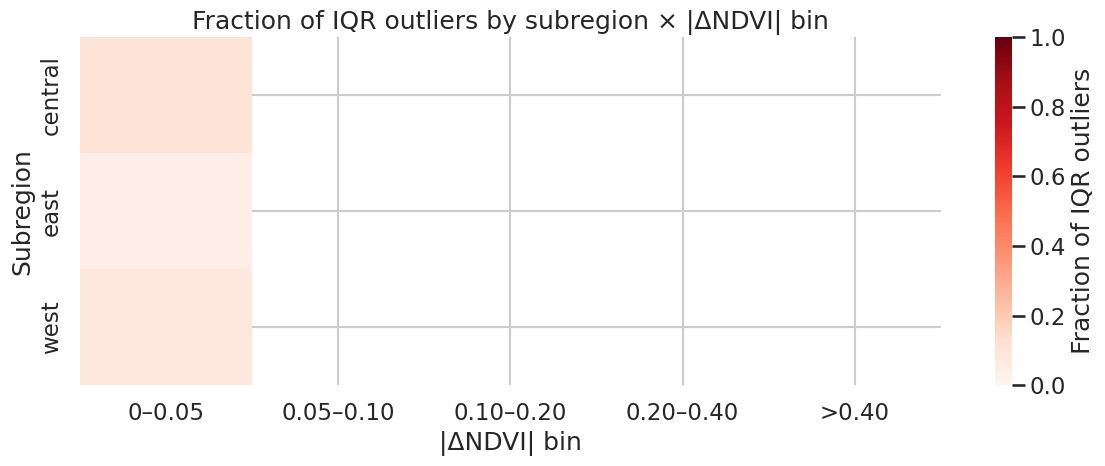

In [20]:
#To check where outliers cluster

#For delta NDVI Values

bins = [0, 0.05, 0.10, 0.20, 0.40, 1.0]
labels = ['0–0.05','0.05–0.10','0.10–0.20','0.20–0.40','>0.40']

work['delta_ndvi_bin'] = pd.cut(
    work['delta_ndvi_abs'],
    bins=bins,
    labels=labels,
    include_lowest=True)

# Create the heatmap

tmp = (work
      .groupby(['subregion', 'delta_ndvi_bin'], dropna=False)['out_iqr']
      .mean()
      .reset_index())

pivot = tmp.pivot(
    index='subregion',
    columns='delta_ndvi_bin',
    values='out_iqr')


plt.figure(figsize=(12, 5))
sns.heatmap(
    pivot,
    cmap='Reds',
    vmin=0, vmax=1,
    cbar_kws={'label': 'Fraction of IQR outliers'}
)

plt.title('Fraction of IQR outliers by subregion × |ΔNDVI| bin')
plt.xlabel('|ΔNDVI| bin')
plt.ylabel('Subregion')
plt.tight_layout()
plt.show()





In [21]:
# The GLM generalizes linear regression by allowing the linear model to be related to the response variable via a link function
#and by allowing the magnitude of the variance of each measurement to be a function of its predicted value.

# Probability that a data point is an outlier (IQR-defined) in ΔAGBD , and the importance of each variable

# “Holding other variables constant, how does this predictor change the odds that a point is an outlier?”

df = work.copy()
df['season_pair'] = np.where(df['season'], 'same', 'different')

model = smf.glm(
    formula="out_iqr ~ C(subregion) + C(season_pair) + post_fire_months + delta_ndvi_abs + agbd_1 + distance_m",
    data=df,
    family=sm.families.Binomial()
).fit()

print(model.summary())

# Convert coefficients to odds ratios
print(np.exp(model.params))


                          Generalized Linear Model Regression Results                          
Dep. Variable:     ['out_iqr[False]', 'out_iqr[True]']   No. Observations:                 4054
Model:                                             GLM   Df Residuals:                     4047
Model Family:                                 Binomial   Df Model:                            6
Link Function:                                   Logit   Scale:                          1.0000
Method:                                           IRLS   Log-Likelihood:                -774.41
Date:                                 Tue, 07 Apr 2026   Deviance:                       1548.8
Time:                                         05:27:43   Pearson chi2:                 5.79e+03
No. Iterations:                                      7   Pseudo R-squ. (CS):             0.1964
Covariance Type:                             nonrobust                                         
                           coef    std e

In [25]:
def add_outlier_flags(df, target='delta_agbd', group_cols=['subregion'], iqr_k=1.5, sd_k=2.5):
    out = df.copy()
    # Ensure numeric
    out[target] = pd.to_numeric(out[target], errors='coerce')

    # Grouping
    g = out.groupby(group_cols, dropna=False)

    # IQR fences
    q1 = g[target].transform(lambda x: x.quantile(0.25))
    q3 = g[target].transform(lambda x: x.quantile(0.75))
    iqr = q3 - q1
    out['iqr_lower'] = q1 - iqr_k * iqr
    out['iqr_upper'] = q3 + iqr_k * iqr
    out['out_iqr'] = (out[target] < out['iqr_lower']) | (out[target] > out['iqr_upper'])

    # SD2.5 fences
    mu = g[target].transform('mean')
    sd = g[target].transform('std')
    out['sd_lower'] = mu - sd_k * sd
    out['sd_upper'] = mu + sd_k * sd
    out['out_sd25'] = (out[target] < out['sd_lower']) | (out[target] > out['sd_upper'])

    return out

filtered = add_outlier_flags(work, target='delta_agbd', group_cols=['subregion'])



In [26]:
#######    I HAVE DECIDED TO USE SD2.5    #########

filtered = filtered[~filtered['out_sd25']]

In [27]:
print("Rows by dataset:")
print(filtered['subregion'].value_counts(dropna=False))

Rows by dataset:
subregion
west       2328
central    1407
east        195
Name: count, dtype: int64


In [ ]:

from scipy.stats import norm

def mark_significance(df, alpha=0.05):
    df = df.copy()
    if 'agbd_se_1' not in df.columns or 'agbd_se_2' not in df.columns:
        for c in ['se_delta','z','p_two_sided','significant','sign_pos','sign_neg']:
            df[c] = np.nan
        return df
    df['se_delta'] = np.sqrt(df['agbd_se_1']**2 + df['agbd_se_2']**2)
    df['z'] = df['delta_agbd'] / df['se_delta']
    df.loc[~np.isfinite(df['z']), 'z'] = np.nan
    df['p_two_sided'] = 2*(1 - norm.cdf(np.abs(df['z'])))
    df['significant'] = df['p_two_sided'] < alpha
    df['sign_pos'] = df['significant'] & (df['delta_agbd'] > 0)
    df['sign_neg'] = df['significant'] & (df['delta_agbd'] < 0)
    return df

DF = mark_significance(GDF)
DF_filt = mark_significance(work)

print("Fraction positive (ALL):", (DF['delta_agbd']>0).mean())
print("Fraction positive (significant only):", DF.loc[DF['significant']==True, 'delta_agbd'].gt(0).mean())


Fraction positive (ALL): 0.6307415825360748
Fraction positive (significant only): 0.7014598540145985


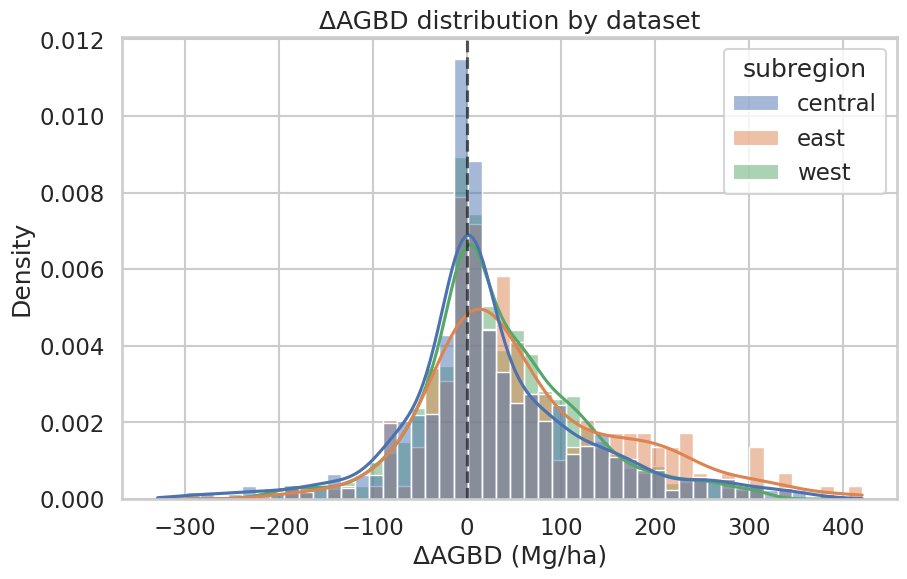

In [28]:
plt.figure(figsize=(10,6))
sns.histplot(data=filtered, x='delta_agbd', hue='subregion', bins=50, kde=True, stat='density', common_norm=False)
plt.axvline(0, color='k', linestyle='--', alpha=0.7)
plt.title('ΔAGBD distribution by dataset')
plt.xlabel('ΔAGBD (Mg/ha)')
plt.ylabel('Density')
plt.show()


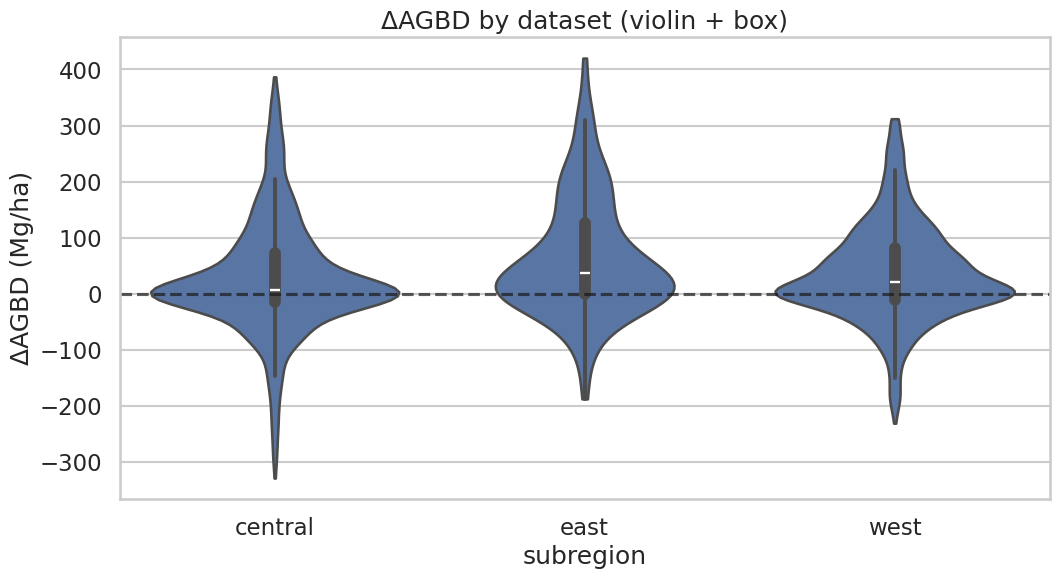

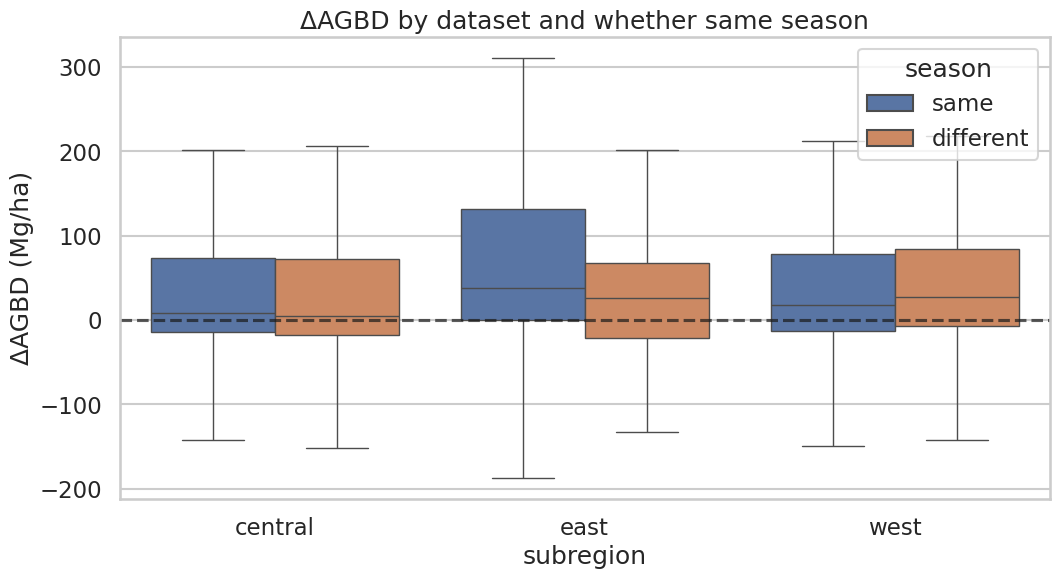

In [30]:

plt.figure(figsize=(12,6))
sns.violinplot(data=filtered, x='subregion', y='delta_agbd', inner='box', cut=0)
plt.axhline(0, color='k', linestyle='--', alpha=0.7)
plt.title('ΔAGBD by dataset (violin + box)')
plt.ylabel('ΔAGBD (Mg/ha)')
plt.show()

plt.figure(figsize=(12,6))
sns.boxplot(data=filtered, x='subregion', y='delta_agbd', hue='season', showfliers=False)
plt.axhline(0, color='k', linestyle='--', alpha=0.7)
plt.title('ΔAGBD by dataset and whether same season')
plt.ylabel('ΔAGBD (Mg/ha)')
plt.show()


In [31]:
print(filtered.columns.tolist())

['pair_uid', 'index_1', 'index_2', 'distance_m', 'fire', 'time_1', 'fire_date', 'time_2', 'season', 'fire_frequency', 'fire_years', 'pre_veg_age', 'post_fire_months', 'agbd_1', 'agbd_2', 'delta_agbd', 'agbd_se_1', 'agbd_se_2', 'rh_98_1', 'rh_98_2', 'rh_90_1', 'rh_90_2', 'rh_50_1', 'rh_50_2', 'cover_1', 'cover_2', 'pai_1', 'pai_2', 'wsci_1', 'wsci_2', 'img_date', 'ndvi_1', 'ndvi_2', 'delta_ndvi', 'delta_ndvi_abs', 'subregion', 'shot_number_1', 'shot_number_2', 'geometry_2', 'geometry', 'dataset', 'iqr_lower', 'iqr_upper', 'out_iqr', 'sd_lower', 'sd_upper', 'out_sd25', 'delta_ndvi_bin']


In [32]:
cols_to_drop = [
    'iqr_lower', 'iqr_upper', 'out_iqr',
    'sd_lower', 'sd_upper', 'out_sd25'
]

filtered = filtered.drop(columns=cols_to_drop)

# Save files
filtered.to_file(out_path, driver='GPKG')
print(f"pairs_SR saved to: {out_path}")

pairs_SR saved to: /content/drive/MyDrive/GEDI/GEDIdb/GEDI__Pairs_Final.gpkg


In [33]:
filtered.head()

,pair_uid,index_1,index_2,distance_m,fire,time_1,fire_date,time_2,season,fire_frequency,fire_years,pre_veg_age,post_fire_months,agbd_1,agbd_2,delta_agbd,agbd_se_1,agbd_se_2,rh_98_1,rh_98_2,rh_90_1,rh_90_2,rh_50_1,rh_50_2,cover_1,cover_2,pai_1,pai_2,wsci_1,wsci_2,img_date,ndvi_1,ndvi_2,delta_ndvi,delta_ndvi_abs,subregion,shot_number_1,shot_number_2,geometry_2,geometry,dataset,delta_ndvi_bin
0,0,11974,12005,3.030845,True,2020-04-21,2020-07-01 00:00:00,2022-04-08,same,2,"2020,2022",NaN,21.0,17.398327,1.947304,15.451023,13.098469,13.108205,15.050000,7.62,13.210000,4.70,1.01,-0.44,0.289419,0.022448,0.683453,0.045408,10.280465,9.688979,None,0.885953277702566,0.8854864594186105,-4.6681828395556124E-4,0.000467,central,76950600400512507,188050500100096756,"POLYGON ((-51.045564 -4.228848, -51.045567 -4....","LINESTRING (-51.04574 -4.22884, -51.04577 -4.2...",None,0–0.05
1,1,5950,6081,3.827840,True,2020-09-21,2022-09-01 00:00:00,2023-01-30,different,4,"1999,2014,2018,2022",2.0,4.0,100.691887,46.000137,54.691750,13.085954,13.095551,14.710000,15.24,12.880000,13.82,3.55,8.46,0.511783,0.670246,1.434349,2.219480,10.127485,10.222557,2020-09-17,0.8026640355204736,0.7994470972606182,-0.0032169382598553,0.003217,central,100590600400693300,234050600400513455,"POLYGON ((-49.643071 -4.824081, -49.643074 -4....","LINESTRING (-49.64328 -4.82409, -49.64327 -4.8...",None,0–0.05
2,2,6084,6085,3.939691,True,2020-09-21,2022-09-01 00:00:00,2023-01-30,different,1,2022,NaN,4.0,55.437439,51.999977,3.437462,13.099988,13.100719,14.940000,14.49,13.820000,13.29,10.86,10.60,0.831974,0.897542,3.570702,4.561275,10.159607,10.002867,2020-09-17,0.836763662171753,0.8389671361502348,0.0022034739784817,0.002203,central,100590600400693299,234050600400513454,"POLYGON ((-49.643369 -4.82366, -49.643372 -4.8...","LINESTRING (-49.64358 -4.82367, -49.64357 -4.8...",None,0–0.05
3,3,28371,28230,4.224179,True,2019-08-28,2020-11-01 00:00:00,2022-08-20,same,2,"2020,2022",NaN,21.0,308.358215,1.279928,307.078278,13.090754,13.111914,18.719999,6.64,16.889999,4.14,11.91,0.18,0.734517,0.128641,2.652961,0.275491,10.456911,9.176444,2019-08-24,0.8529956763434219,0.8531919317945519,0.00019625545113,0.000196,central,40110500100100256,208800500100100794,"POLYGON ((-49.66251 -4.462863, -49.662513 -4.4...","LINESTRING (-49.66268 -4.46282, -49.66271 -4.4...",None,0–0.05
5,5,7041,7043,5.679063,True,2020-08-20,2020-09-01 00:00:00,2022-05-24,different,2,"2020,2022",NaN,20.0,96.419365,1.286733,95.132629,13.142453,13.111748,31.530001,6.53,14.080000,4.03,1.42,0.14,0.197622,0.059466,0.440373,0.122627,10.312894,9.129178,2020-08-23,0.4570637119113573,0.4539382131923184,-0.0031254987190389,0.003125,central,95711100400334706,195221100100100348,"POLYGON ((-49.557214 -5.01214, -49.557217 -5.0...","LINESTRING (-49.55739 -5.01216, -49.55742 -5.0...",None,0–0.05
